In [270]:
import os
from typing import TypedDict, Annotated, List, Dict, Any
import gradio as gr
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv
from IPython.display import Image, display
import fitz
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, AIMessage, ToolMessage


In [271]:
class State(TypedDict):
    """
    The state for our LangGraph agent.
    """
    # documents: List[str] # List of document identifiers
    chat_history: Annotated[list[dict[str, str]], add_messages]
    query: str
    response: str
    document: Dict[str, str]
    extracted_text: Dict[str, str]
    summary: str
    question_list: List[str]
    s3Uri: Dict[str, str]
    result_url: Dict[str, str]
    bda_result: Dict[str, str]
    messages: Annotated[list, add_messages]
    # is_inter_document_query: bool

In [272]:
load_dotenv(override=True)

GEMINI_BASE_URL = os.getenv("GEMINI_BASE_URL")
GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY")
GEMINI_API_KEY = os.getenv("GEMINI_API_KEY")
llm = init_chat_model("google_genai:gemini-2.5-flash")

In [273]:
import base64
import fitz  # PyMuPDF
import boto3
from io import BytesIO
import logging
from urllib.parse import urlparse
from langchain_core.tools import tool
import json
import uuid
# from langgraph.checkpoint import get_state

logger = logging.getLogger()
logger.setLevel(logging.INFO)

@tool
def extract_image_from_pdf_bbox(filename: str, geometry: Dict[str, Any]):
    """
    Tool to crop an image from a PDF stored in S3 using bounding box details
    and upload the cropped image back to S3.

    Args:
        filename (str): Name of the PDF file (must exist in state["s3Uri"])
        geometry (dict): {
            "boundingBox": {
                "left": float,
                "top": float,
                "width": float,
                "height": float
            },
            "page": int
        }
    Returns:
        dict: {
            "success": bool,
            "s3Url": "<uploaded_image_s3_url>"
        }
    """

    graph_state = graph.get_state(config)
    state = dict(graph_state.values)
    
    try:
        if not filename or not geometry:
            return {"error": "Missing filename or geometry"}

        bbox = geometry.get("boundingBox")
        if not bbox:
            return {"error": "Missing boundingBox in geometry"}

        # ✅ Lookup S3 URI from state (hidden from LLM)
        if state is None:
            return {"error": "State not provided to tool"}

        s3_uri = state["s3Uri"].get(filename)
        if not s3_uri:
            return {"error": f"No S3 URI found in state for '{filename}'"}

        parsed = urlparse(s3_uri)
        bucket = parsed.netloc
        key = parsed.path.lstrip("/")

        # Download PDF from S3
        s3 = boto3.client("s3")
        obj = s3.get_object(Bucket=bucket, Key=key)
        pdf_bytes = obj["Body"].read()

        # Open PDF with PyMuPDF
        doc = fitz.open(stream=BytesIO(pdf_bytes), filetype="pdf")
        page_num = int(geometry.get("page", 1)) - 1  # 0-indexed
        if page_num >= len(doc):
            return {"error": f"Invalid page number: {page_num + 1}"}

        page = doc.load_page(page_num)
        page_width, page_height = page.rect.width, page.rect.height

        # Normalized bbox -> absolute coordinates
        x0 = bbox["left"] * page_width
        y0 = bbox["top"] * page_height
        x1 = x0 + (bbox["width"] * page_width)
        y1 = y0 + (bbox["height"] * page_height)

        # Apply padding (10%)
        width = x1 - x0
        height = y1 - y0
        padding_x = width * 0.1
        padding_y = height * 0.1

        x0 = max(0, x0 - padding_x)
        y0 = max(0, y0 - padding_y)
        x1 = min(page_width, x1 + padding_x)
        y1 = min(page_height, y1 + padding_y)

        rect = fitz.Rect(x0, y0, x1, y1)
        matrix = fitz.Matrix(2.0, 2.0)  # upscale for clarity
        pix = page.get_pixmap(matrix=matrix, clip=rect)
        image_bytes = pix.tobytes("png")

        doc.close()

        output_bucket = bucket  # default: same as source PDF
        # Choose output bucket
        # if not outputS3Bucket:
        #     output_bucket = bucket  # default: same as source PDF
        # else:
        #     output_bucket = outputS3Bucket
        image_key = f"cropped_images/{uuid.uuid4().hex}.png"

        # Upload cropped image
        s3.put_object(
            Bucket=output_bucket,
            Key=image_key,
            Body=image_bytes,
            ContentType="image/png"
        )

        s3_url = f"https://{output_bucket}.s3.amazonaws.com/{image_key}"

        return {"success": True, "s3Url": s3_url}

    except Exception as e:
        logger.error(f"Cropping/upload error: {str(e)}")
        return {"error": str(e)}

In [274]:
# result = extract_image_from_pdf_bbox.invoke({'state': {'s3Uri': {'144255Store Pack.pdf': 's3://document-processing-agent-pratik/uploads/6bc74cf2-4dbb-46e1-8ece-4f8d5121ba45/144255Store Pack.pdf'}}, 'inputs': {'geometry': {'page': 1.0, 'boundingBox': {'height': 0.017244239934959882, 'left': 0.19751502127328932, 'top': 0.43722645437088303, 'width': 0.08726097532846325}}, 'filename': '144255Store Pack.pdf'}})
# result = extract_image_from_pdf_bbox.invoke({'filename': '132065Store Pack.pdf', 'geometry': {'page': 1.0, 'boundingBox': {'left': 0.1943820919991585, 'width': 0.09671107086551434, 'top': 0.4430921912278827, 'height': 0.018103803575746424}}})
# print(result)


In [275]:
from langchain_core.tools import Tool

# Register the tool
# image_tool = Tool(
#     name="extract_image_from_bbox",
#     description="Extracts a cropped image from a document in S3 using LLM-supplied bounding box.",
#     func=extract_image_from_bbox
# )
tools = [extract_image_from_pdf_bbox]

# Bind tools to your LLM
llm_with_tools = llm.bind_tools(tools)

In [276]:
extract_image_from_pdf_bbox.args_schema.schema()


C:\Users\PratikTalaviya\AppData\Local\Temp\ipykernel_8508\1859862078.py:1: PydanticDeprecatedSince20: The `schema` method is deprecated; use `model_json_schema` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.11/migration/
  extract_image_from_pdf_bbox.args_schema.schema()


{'description': 'Tool to crop an image from a PDF stored in S3 using bounding box details\nand upload the cropped image back to S3.\n\nArgs:\n    filename (str): Name of the PDF file (must exist in state["s3Uri"])\n    geometry (dict): {\n        "boundingBox": {\n            "left": float,\n            "top": float,\n            "width": float,\n            "height": float\n        },\n        "page": int\n    }\nReturns:\n    dict: {\n        "success": bool,\n        "s3Url": "<uploaded_image_s3_url>"\n    }',
 'properties': {'filename': {'title': 'Filename', 'type': 'string'},
  'geometry': {'additionalProperties': True,
   'title': 'Geometry',
   'type': 'object'}},
 'required': ['filename', 'geometry'],
 'title': 'extract_image_from_pdf_bbox',
 'type': 'object'}

In [277]:
tools

[StructuredTool(name='extract_image_from_pdf_bbox', description='Tool to crop an image from a PDF stored in S3 using bounding box details\nand upload the cropped image back to S3.\n\nArgs:\n    filename (str): Name of the PDF file (must exist in state["s3Uri"])\n    geometry (dict): {\n        "boundingBox": {\n            "left": float,\n            "top": float,\n            "width": float,\n            "height": float\n        },\n        "page": int\n    }\nReturns:\n    dict: {\n        "success": bool,\n        "s3Url": "<uploaded_image_s3_url>"\n    }', args_schema=<class 'langchain_core.utils.pydantic.extract_image_from_pdf_bbox'>, func=<function extract_image_from_pdf_bbox at 0x000002011BD5FBA0>)]

In [278]:
from PIL import ImageEnhance, ImageFilter

def preprocess_image(image):
    # Convert to grayscale
    image = image.convert('L')
    # Increase contrast
    enhancer = ImageEnhance.Contrast(image)
    image = enhancer.enhance(2)
    # Apply sharpening
    image = image.filter(ImageFilter.SHARPEN)
    return image

In [279]:
# import pytesseract
# from pdf2image import convert_from_bytes

# def extract_text_with_ocr(file_bytes):
#     """Extract text from scanned/image-based PDF using Tesseract OCR."""
#     text = ""
#     images = convert_from_bytes(file_bytes)
#     for img in images:
#         text += pytesseract.image_to_string(img)
#     return text

import fitz  # PyMuPDF
import pytesseract
from PIL import Image
import io
import numpy as np

pytesseract.pytesseract.tesseract_cmd = r"C:\Users\PratikTalaviya\AppData\Local\Programs\Tesseract-OCR\tesseract.exe"

def extract_text_with_ocr_tesseract(file_bytes):
    """
    Render PDF pages as images using PyMuPDF and extract text via Tesseract OCR.
    """
    text = ""
    # Open PDF
    with fitz.open(stream=file_bytes, filetype="pdf") as doc:
        for page_num, page in enumerate(doc):
            # Render page to a pixmap (RGB)
            pix = page.get_pixmap(alpha=False)
            # img = Image.frombytes("RGB", [pix.width, pix.height], pix.samples)
            # # OCR on image
            # Convert pixmap to NumPy array
            img_array = np.frombuffer(pix.samples, dtype=np.uint8).reshape(pix.height, pix.width, pix.n)
            
            # Convert NumPy array to PIL Image
            img = Image.fromarray(img_array)
            img = preprocess_image(img)
            page_text = pytesseract.image_to_string(img)
            text += page_text + "\n"
    return text

In [280]:
from pydantic import BaseModel, Field, field_validator
import json


class llmOutput(BaseModel):
    text_message: str = Field(
        description="Text message to user from llm"
    )
    image_urls: Dict[str, str] = Field(
        default_factory=dict,
        description="Dictionary with key as name of the image extracted and values as S3 URLs of cropped image if generated using tool by llm else empty"
    )
    @field_validator("image_urls", mode="before")
    def parse_json_dict(cls, v):
        if isinstance(v, str):
            try:
                return json.loads(v)
            except Exception:
                raise ValueError("image_urls must be a valid JSON object")
        return v

def llm_generation(state: State):
    print("---NODE : LLM GENERATION---")
    response_prompt = state["bda_result"]
    prev_messages = state.get("messages", [])
    chat_history = state.get("chat_history", [])
    messages = state.get("messages", [])

    if not state["query"].strip():

        return {
            "response": [{"text_message": "Your query was empty. Can you clarify?", "image_urls": []}],
        }


    # 2) Build enriched prompt ONLY for the current LLM call
    # enriched_prompt = f"""
    # You are a helpful assistant.

    # Follow these rules:
    # 1) Always summarize any tool's output for the user in plain language.
    # 2) If a tool returns an Image URL, include it in your response so the user can see the image.
    # 3) If the user asks for an image, or the query involves a signature (e.g., verify, locate, read, or compare a signature), USE the extract image tool to crop the relevant region and return the cropped image URL.
    # 4) For any signature-related query, ALWAYS include the cropped image in your response for clarity.
    # 5) Never return an empty response. If the user’s request is unclear, ask exactly ONE concise clarifying question before answering.
    # 6) Keep your answer concise, accurate, and directly actionable.

    # Context to use: '{response_prompt}'
    # S3 Uri for Cropping Tool'{state['s3Uri']}'
    # User query : '{state['query']}' 

    # Your task:
    # - Provide the best possible answer using the context and tools.
    # - If you used a tool, briefly summarize what it returned.
    # - If the query is unclear, ask one short clarifying question first (do not leave the message blank).
    # """
    enriched_prompt = f"""
    You are a helpful assistant. 
    - Summarize tool outputs for the user.
    - If a tool returns an Image URL, include it.
    - For signature-related queries only, always crop the signature and show the cropped image URL also provide context of the signature.
    - For other images if asked then only crop them and use details from context for cropping do not generate 
    - Never give empty responses. If unclear, ask ONE clarifying question.
    - If multiple bounding box found for same field merge it into single one.
    Context: {response_prompt}
    User query: {state['query']}
    """
    # S3 URI: {state['s3Uri']}

    enriched_human = HumanMessage(content=enriched_prompt)

    messages.append(enriched_human)

    # 3) WORKING messages for LLM call
    # working_messages = sanitized_prev + [enriched_human]

    # 4) Call LLM
    ai_message = llm_with_tools.invoke(messages)
    if not ai_message.content.strip():
        ai_message.content = "I could not generate a proper response. Could you rephrase your question?"


    # 5) Structure AI response
    # structure_prompt = f"""
    # You are a response formatter.
    # Your job:
    # - Convert the following AI response into the exact structured format defined by the schema.
    # - Do NOT add extra words, explanations, or formatting outside the schema.
    # - If no image URL is present, return an empty list [] for image_urls.
    # - Always return valid JSON that strictly matches the schema fields.
    # - You can remove image urls from text_message.
    # Schema:
    # {{
    # "text_message": "string - the assistant's reply to the user",
    # "image_urls": ["list of S3 URLs if tool generated cropped images, else empty list"]
    # }}
    # AI Response to structure:
    # "{ai_message.content}"
    # """
    structure_prompt = f"""
    You are a response formatter.
    Your job:
    - Convert the following AI response into structured out defined.
    - Do NOT add extra words, explanations, or formatting.
    - If no image URL is present, return an empty dict for image_urls.
    - You can remove image urls from text_message.
    AI Response to structure:
    "{ai_message.content}"
    """
    structured_llm = llm.with_structured_output(llmOutput)
    final_response = structured_llm.invoke(structure_prompt)
    response_list = [final_response.model_dump()]


    messages.pop()
    messages.append(HumanMessage(content=state["query"]))
    messages.append(ai_message)

    return {
        "response": response_list,
        "messages": messages,
    }



def context_generation(state: State):
    """
    Node to extract text from PDF bytes.
    """
    print("---NODE: PDF TEXT EXTRACTION---")
    
    file_bytes_dict = state.get("document")
    if not file_bytes_dict:
        raise ValueError("No file bytes found in state")
    
    extracted_data = {}

    for file_name, file_bytes in file_bytes_dict.items():
        pdf_text = ""
        with fitz.open(stream=file_bytes, filetype="pdf") as doc:
            for page in doc:
                pdf_text += page.get_text()

        if not pdf_text.strip():
            print(f"[OCR] Running OCR for {file_name}...")
            pdf_text = extract_text_with_ocr_tesseract(file_bytes) 
            # pdf_text = extract_text_with_ocr_easyocr(file_bytes) 

        extracted_data[file_name] = pdf_text

    print(extracted_data)
    # Add extracted text to state
    return {
        # **state,  # Keep previous state keys
        "extracted_text": extracted_data,
        "document": None
    }


def should_extract(state):
    """Condition function: returns next node name based on state."""
    print(state)
    if state.get("document"):  # already has text
        return "s3Upload"

    return "generation"

In [281]:
from pydantic import BaseModel, Field

class summaryDocuments(BaseModel):
    summary: str = Field(
        description="Summary of all the documents upload by the user"
    )
    questions: List[str] = Field(
        description="List of the Question user can directly ask only three questions regarding documents passed"
    )

def summarize_documents(state: State):
    print("---NODE: SUMMARIZATION OF DOUCMENTS---")
    extracted_text = state["extracted_text"]
    summarization_prompt = f"""
    You have been given data of the documents which will be used to answer user question regaring the documents and information filled in that documents. And user can ask inter-document question as well.
    Here is the Text of all documents :
    {extracted_text}
    Based on the Extracted Text from the Documents it can be single and multiple you have to create a short summary of all the document, and provide three question user can directly asked regarding those documents if possible regarding the fields filled in the documents. 
    """
    response = llm.with_structured_output(summaryDocuments).invoke(summarization_prompt)

    summary = response.summary
    questions = response.questions

    state["summary"] = summary
    state["question_list"] = questions

    return state



In [282]:
# Upload Documents to S3
import boto3
from botocore.exceptions import ClientError
import uuid

def s3_upload_node(state: State):
    """
    Node to upload uploaded PDF files (bytes) to an S3 bucket.
    Returns state with S3 URIs for each file.
    """
    print("---NODE: S3 UPLOAD---")

    file_bytes_dict = state.get("document")
    if not file_bytes_dict:
        raise ValueError("No file bytes found in state")

    bucket_name = "document-processing-agent-pratik"   
    s3_client = boto3.client("s3")

    uploaded_files = {}

    for file_name, file_bytes in file_bytes_dict.items():
        try:
            # Generate unique key for each file
            unique_key = f"uploads/{uuid.uuid4()}/{file_name}"

            # Upload to S3
            s3_client.put_object(
                Bucket=bucket_name,
                Key=unique_key,
                Body=file_bytes,
                ContentType="application/pdf"
            )

            # Construct S3 URI
            s3_uri = f"s3://{bucket_name}/{unique_key}"
            uploaded_files[file_name] = s3_uri
            print(f"Uploaded {file_name} -> {s3_uri}")

        except ClientError as e:
            print(f"Error uploading {file_name}: {e}")
            raise

    # Update state with S3 URIs
    return {
        "s3Uri": uploaded_files,
        "document": None
    }



In [283]:
# Node for BDA processing of documents

import boto3
import time
import uuid
from botocore.exceptions import ClientError

def bda_process_node(state: dict):
    """
    Node to process documents in S3 via Bedrock Data Automation.
    Uses a previously created project ARN (or creates one),
    invokes processing for each file, polls for completion, and
    records output URIs in state.
    Requires:
      - state["s3_documents"]: dict {file_name: s3_uri}
      - state["bda_project_arn"]: optional existing project ARN
      - AWS credentials and permissions for Bedrock and S3
    Returns:
      - state["bda_results"]: {file_name: job_output_s3_uri}
    """
    print("---NODE: BDA DOCUMENT PROCESSING---")

    s3_docs = state.get("s3Uri")
    if not s3_docs:
        raise ValueError("No S3 documents found in state")

    client = boto3.client("bedrock-data-automation-runtime")
    project_arn = "arn:aws:bedrock:us-east-1:970547377074:data-automation-project/570db58af251"

    # Optionally create a project if missing
    # if not project_arn:
    #     print("Creating BDA project...")
    #     project_name = f"doc-processing-{uuid.uuid4()}"
    #     response = client.create_data_automation_project(
    #         projectName=project_name,
    #         projectDescription="Auto-generated project for document processing",
    #         projectStage='LIVE',
    #         standardOutputConfiguration={
    #             "document": {"state": "ENABLED"}
    #         }
    #         # add overrideConfiguration, customOutputConfiguration, etc. as needed
    #     )
    #     project_arn = response["dataAutomationProjectArn"]
    #     print(f"Created project ARN: {project_arn}")
    #     state["bda_project_arn"] = project_arn

    results = {}
    output_s3Uri = "s3://document-processing-agent-pratik/BDA"
    profile_arn = os.getenv('DATA_AUTOMATION_PROFILE_ARN')
    
    jobs = {}
    for fname, s3_uri in s3_docs.items():
        print(f"Invoking BDA processing for {fname}...")
        invoke_resp = client.invoke_data_automation_async(
            dataAutomationConfiguration={"dataAutomationProjectArn": project_arn, "stage": "LIVE"},
            inputConfiguration={"s3Uri": s3_uri},
            outputConfiguration={"s3Uri": output_s3Uri},
            dataAutomationProfileArn=profile_arn,
            clientToken=str(uuid.uuid4())
        )
        invocation_arn = invoke_resp["invocationArn"]
        print(f"Invocation ARN for {fname}: {invocation_arn}")
        jobs[invocation_arn] = fname  # map ARN → file

    # -------------------------------
    # 2. Poll until all complete
    # -------------------------------
    pending = set(jobs.keys())
    while pending:
        finished = []
        for invocation_arn in list(pending):
            fname = jobs[invocation_arn]
            status_resp = client.get_data_automation_status(invocationArn=invocation_arn)
            status = status_resp["status"]

            print(f"Status for {fname}: {status}")

            if status == "Success":
                output_uri = status_resp["outputConfiguration"]["s3Uri"]
                print(f"Processing successful for {fname}. Output at: {output_uri}")
                results[fname] = output_uri
                finished.append(invocation_arn)

            elif status in ["ClientError", "ServiceError"]:
                error = status_resp.get("statusMessage", "Unknown error")
                raise RuntimeError(f"BDA processing failed for {fname}: {error}")

            # else still Running/Queued → skip

        # Remove finished jobs
        for arn in finished:
            pending.remove(arn)

        if pending:
            time.sleep(5)  # back off before next poll

    state["result_url"] = results
    return state


In [284]:
# bda_process_node({'s3Uri': {'144255BILL OF SALE.pdf': 's3://document-processing-agent-pratik/uploads/98f972eb-0df4-4100-affb-b38eb7824148/144255BILL OF SALE.png'}})

In [285]:
#Node for parsing the result from s3 stored by BDA

import os
import boto3
import json
from urllib.parse import urlparse

def extract_explainability_info(explainability_info):
    cleaned_info = []
    for section in explainability_info:  # each top-level dict
        cleaned_section = {}
        for group_name, fields in section.items():
            cleaned_group = {}

            # CASE 1: group_name itself is a single field (has success/confidence/geometry etc.)
            if isinstance(fields, dict) and "geometry" in fields:
                bboxes = []
                for g in fields["geometry"]:
                    if "boundingBox" in g:
                        bboxes.append({
                            "boundingBox": g["boundingBox"],
                            "page": g.get("page")
                        })
                if bboxes:
                    cleaned_section[group_name] = bboxes

            # CASE 2: group_name contains subfields (like VehicleInformation -> VIN, Model, etc.)
            elif isinstance(fields, dict):
                for field_name, field_data in fields.items():
                    if isinstance(field_data, dict) and "geometry" in field_data:
                        bboxes = []
                        for g in field_data["geometry"]:
                            if "boundingBox" in g:
                                bboxes.append({
                                    "boundingBox": g["boundingBox"],
                                    "page": g.get("page")
                                })
                        if bboxes:
                            cleaned_group[field_name] = bboxes

                if cleaned_group:
                    cleaned_section[group_name] = cleaned_group

        if cleaned_section:
            cleaned_info.append(cleaned_section)
    return cleaned_info


def bda_extract_results_node(state: dict):
    """
    Node to extract BDA processing results from S3 and store in state.
    Handles both single and merged PDF outputs.
    
    Expects:
      - state["bda_results"]: {filename: job_metadata.json S3 URI}
    Produces:
      - state["parsed_results"]: {filename: { blueprint_name: [extracted_result_json, ...] }}
    """
    print("---NODE: BDA RESULT EXTRACTION---")


    bda_results = state.get("result_url")
    if not bda_results:
        raise ValueError("No BDA results found in state")

    s3_client = boto3.client("s3")
    parsed_results = {}

    for fname, s3_url in bda_results.items():
        try:
            parsed = urlparse(s3_url)
            bucket = parsed.netloc
            job_prefix = parsed.path.lstrip("/").rsplit("/", 1)[0]  # up to /0

            # List all result.json files under job_prefix/custom_output/*
            response = s3_client.list_objects_v2(
                Bucket=bucket,
                Prefix=f"{job_prefix}/0/custom_output/"
            )
            
            if "Contents" not in response:
                print(f"No results found for {fname}")
                continue

            merged_file_results = {}

            for obj in response.get("Contents"):
                key = obj["Key"]
                if not key.endswith("result.json"):
                    continue

                print(f"Fetching result for {fname}: s3://{bucket}/{key}")
                content = s3_client.get_object(Bucket=bucket, Key=key)["Body"].read().decode("utf-8")
                json_data = json.loads(content)

                # Extract blueprint name safely
                blueprint_name = json_data.get("matched_blueprint").get("name")
                print(blueprint_name)
                if not blueprint_name:
                    blueprint_name = "UNKNOWN_BLUEPRINT"

                # Extract useful fields
                result_obj = {
                    "inference_result": json_data.get("inference_result"),
                    "explainability_info": extract_explainability_info(json_data.get("explainability_info")),
                }

                # Store under blueprint → subfile → result
                if blueprint_name not in merged_file_results:
                    merged_file_results[blueprint_name] = {}

                subfile_name = key.split("/")[-2]  # e.g., "0", "1", "2" folder name
                merged_file_results[blueprint_name][subfile_name] = result_obj

            parsed_results[fname] = merged_file_results
            print(f"Extracted result for {fname}")

        except Exception as e:
            print(f"Error extracting result for {fname}: {e}")
            parsed_results[fname] = {"error": str(e)}
    print("Successfully Extracted")
    return {"bda_result": parsed_results}


In [286]:
import boto3
import json
from urllib.parse import urlparse
from concurrent.futures import ThreadPoolExecutor, as_completed

def fetch_s3_json(s3_client, bucket, key):
    """Helper to fetch JSON from S3 and decode"""
    content = s3_client.get_object(Bucket=bucket, Key=key)["Body"].read().decode("utf-8")
    return json.loads(content)

def parse_standard_output(std_json: dict) -> str:
    """
    Extract only markdown text from standard_output JSON.
    Keeps reading order.
    """
    elements = std_json.get("elements", [])
    # sort by reading_order if available
    elements_sorted = sorted(
        elements, key=lambda e: e.get("reading_order", 1e9)
    )
    texts = []
    for elem in elements_sorted:
        rep = elem.get("representation", {})
        if "markdown" in rep:
            texts.append(rep["markdown"].strip())
    return "\n\n".join(texts)

def extract_standard_output_node(state: dict):
    """
    Extract standard output text from BDA job results.
    
    Expects:
      - state["result_url"]: { filename: s3://bucket/jobmetadata.json }
    
    Produces:
      - state["extracted_text"]: { filename: { segment_id: "markdown text..." } }
    """
    print("---NODE: STANDARD OUTPUT EXTRACTION---")

    result_urls = state.get("result_url")
    if not result_urls:
        raise ValueError("No job metadata S3 URLs found in state['result_url']")

    s3_client = boto3.client("s3")
    extracted_texts = {}

    for fname, metadata_s3_url in result_urls.items():
        try:
            # Parse the jobmetadata.json S3 path
            parsed = urlparse(metadata_s3_url)
            bucket = parsed.netloc
            key = parsed.path.lstrip("/")

            print(f"Fetching job metadata for {fname}: {metadata_s3_url}")
            metadata = fetch_s3_json(s3_client, bucket, key)

            # Traverse output_metadata → segment_metadata → standard_output_path
            futures = {}
            with ThreadPoolExecutor(max_workers=8) as executor:
                for asset in metadata.get("output_metadata", []):
                    for seg_idx, segment in enumerate(asset.get("segment_metadata", [])):
                        std_path = segment.get("standard_output_path")
                        if std_path:
                            parsed_std = urlparse(std_path)
                            futures[executor.submit(
                                fetch_s3_json,
                                s3_client,
                                parsed_std.netloc,
                                parsed_std.path.lstrip("/")
                            )] = seg_idx

                segment_results = {}
                for future in as_completed(futures):
                    seg_idx = futures[future]
                    try:
                        std_json = future.result()
                        markdown_text = parse_standard_output(std_json)
                        segment_results[str(seg_idx)] = markdown_text
                    except Exception as e:
                        print(f"Error fetching standard output for {fname}, segment {seg_idx}: {e}")
                        segment_results[str(seg_idx)] = {"error": str(e)}

                extracted_texts[fname] = segment_results

        except Exception as e:
            print(f"Error processing job metadata for {fname}: {e}")
            extracted_texts[fname] = {"error": str(e)}
    print("Successfully Extracted")
    return {"extracted_text": extracted_texts}


In [287]:
# extract_standard_output_node({
#     "result_url": {
#         "merged_documents_132065.pdf": "s3://document-processing-agent-pratik/BDA/7aae1595-8899-407a-aa45-742ba071e8c4/job_metadata.json"
#     }
# })

In [288]:
# bda_extract_results_node({'bda_result': {'144255BILL OF SALE.pdf': 's3://document-processing-agent-pratik/BDA/f40ee255-7b71-4119-a944-baf00e6a355f/job_metadata.json'}})

In [289]:
from langgraph.prebuilt import ToolNode
from langchain_core.messages import ToolMessage


memory = InMemorySaver()
workflow = StateGraph(State)

def should_continue(state: State):
    messages = state["messages"]
    last_message = messages[-1]
    if last_message.tool_calls:
        return "tools"
    return END

# Add the ToolNode
tool_node = ToolNode(tools)
workflow.add_node("tools", tool_node)

# Route dynamically based on whether the LLM called the tool
workflow.add_conditional_edges(
    "generation",
    should_continue,
    ["tools", END]
)

# Loop back so LLM can respond post-tool execution
workflow.add_edge("tools", "generation")

workflow.add_node("generation", llm_generation)
# workflow.add_node("extraction", context_generation)
workflow.add_node("summarization", summarize_documents)
workflow.add_node("s3Upload", s3_upload_node )
workflow.add_node("bdaProcessing", bda_process_node)
workflow.add_node("bdaResult", bda_extract_results_node)
workflow.add_node("textExtraction", extract_standard_output_node)

# workflow.add_edge(START, "s3Upload")
workflow.add_conditional_edges(
    START,
    should_extract,
    {
        "s3Upload": "s3Upload",  # go to extraction if no text
        "generation": "generation"   # skip extraction if already done
    }
)
workflow.add_edge("s3Upload", "bdaProcessing")
workflow.add_edge("bdaProcessing", "bdaResult")
workflow.add_edge("bdaProcessing", "textExtraction")
# workflow.add_edge("bdaResult", "extraction")
workflow.add_edge(["textExtraction", "bdaResult"], "summarization")
workflow.add_edge("generation", END)

graph = workflow.compile(checkpointer=memory)

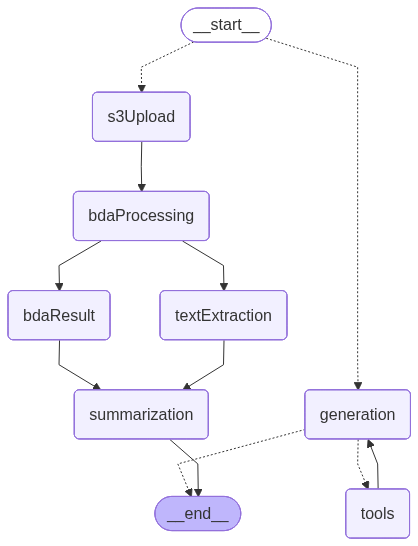

In [290]:
from IPython.display import Image as img, display

display(img(graph.get_graph().draw_mermaid_png()))


In [ ]:
import json
session_id = "user-session-1"
config = {"configurable": {"thread_id": "1"}}

initial_state = {
    "document": None,
    "chat_history": [],
    "query": "",
    "response": "",
    "extracted_text": {},
    "bda_result":{},
    "s3Uri":{},
    "summary" : "",
    "question_list": [],

}

graph.update_state(config, values=initial_state, task_id=session_id)

def process_document(files):
    """Function to handle document upload and ingestion."""
    if files is None:
        return "Please upload a document first."
    file_bytes_list = {}
    # Read file bytes
    print(files)
    for file in files:
        file_bytes = ""
        with open(file.name, "rb") as f:
            file_bytes = f.read()
        file_bytes_list[os.path.basename(file.name)] = file_bytes

    current_state = graph.get_state(config)
    state_dict = dict(current_state.values)

    # Now you can modify it
    state_dict["document"] = file_bytes_list
    print(file_bytes_list.keys())
    # Invoke the graph with the updated dict
    text = graph.invoke(state_dict, config)
    # Persist updated state
    # graph.update_state(config, values=state_dict, task_id=session_id)
    print(text["question_list"])
    summary = text.get("summary", "No summary generated")
    questions = text.get("question_list", [])
    return summary, [[q] for q in questions]


# --- Chat Handler ---
def chat_interface(query, history):
    """Handle user chat messages with text + images using messages format."""
    if history is None:
        history = []

    # get & update state
    current_state = graph.get_state(config)
    state_dict = dict(current_state.values)
    state_dict["query"] = query

    # model response
    graph_state = graph.invoke(state_dict, config)
    ai_message = graph_state.get("response")
    # --- normalize to Python types ---
    if hasattr(ai_message, "model_dump"):       # pydantic v2
        ai_message = ai_message.model_dump()
    elif hasattr(ai_message, "dict"):           # pydantic v1
        ai_message = ai_message.dict()
    elif isinstance(ai_message, str):
        try:
            ai_message = json.loads(ai_message)  # stringified JSON
        except Exception:
            # fallback: just show raw text
            history = history + [{"role": "user", "content": query},
                                 {"role": "assistant", "content": ai_message}]
            return history

    # ensure list-of-dicts shape like your example
    if isinstance(ai_message, dict):
        ai_message = [ai_message]
    if not isinstance(ai_message, list) or not ai_message:
        # absolute fallback
        history = history + [{"role": "user", "content": query},
                             {"role": "assistant", "content": str(ai_message)}]
        return history

    payload = ai_message[0] or {}
    text_msg = payload.get("text_message")
    image_urls = payload.get("image_urls") or {}

    # --- build messages (messages format) ---
    # 1) append the user turn
    history = history + [{"role": "user", "content": query}]

    # 2) assistant text (if any)
    if text_msg:
        history.append({"role": "assistant", "content": str(text_msg)})

    for name, url in image_urls.items():
    # Add the name/label as a text message
        history.append({
            "role": "assistant",
            "content": f"**{name}**"   # markdown for bold name
        })
        # Add the image itself
        history.append({
            "role": "assistant",
            "content": gr.Image(value=str(url), show_label=False)
        })

    return history



current_state_snapshot = graph.get_state(config)
current_state = current_state_snapshot.values

with gr.Blocks(title="Document Processing Agent",css=".btn {height : 60px;}") as demo:
    gr.Markdown("# LangGraph Document Agent")
    with gr.Row():
        with gr.Column(scale=1):
            file_upload = gr.File(label="Upload Documents", file_count="multiple")
            process_button = gr.Button("Process Document", variant="primary")
            ingestion_output = gr.Textbox(label="Document Processing Status And Summary", value=current_state['summary'])

        with gr.Column(scale=2):
            chatbot = gr.Chatbot(label="Chat with Agent", type="messages")
            with gr.Row():
                user_input = gr.Textbox(scale=8, show_label=False, submit_btn=True, placeholder="")
                # send_button = gr.Button("Send", scale=2, variant="primary", elem_classes="btn")

            # Use Dataset instead of Examples
            suggested_examples = gr.Dataset(
                # visible=show_question,
                label="Suggested Questions",
                headers=["Suggested Questions"],
                components=[gr.Textbox(visible=False)],
                samples= [[q] for q in current_state['question_list']]
            )

    # --- Wire events ---
    def process_and_update(files):
        summary, questions = process_document(files)
        return summary, gr.update(samples=questions)

    process_button.click(
        fn=process_and_update,
        inputs=file_upload,
        outputs=[ingestion_output, suggested_examples]
    )

    # Clicking dataset row autofills textbox
    def load_example(row):
        return row[0]

    suggested_examples.select(fn=load_example, inputs=[suggested_examples], outputs=[user_input])

    # send_button.click(fn=chat_interface, inputs=[user_input, chatbot], outputs=chatbot)
    user_input.submit(fn=chat_interface, inputs=[user_input, chatbot], outputs=chatbot)

demo.launch()


{'document': None, 'chat_history': [], 'query': '', 'response': '', 'extracted_text': {}, 'bda_result': {}, 's3Uri': {}, 'summary': '', 'question_list': [], 'messages': []}
* Running on local URL:  http://127.0.0.1:7872
* To create a public link, set `share=True` in `launch()`.


['C:\\Users\\PratikTalaviya\\AppData\\Local\\Temp\\gradio\\549797d53def4c63493973489d0f211f7a4c47b4877e3f0ccbb43447e1537a30\\ilovepdf_merged.pdf']
dict_keys(['ilovepdf_merged.pdf'])
{'chat_history': [], 'query': '', 'response': '', 'document': {'ilovepdf_merged.pdf': b'%PDF-1.7\n%\xe2\xe3\xcf\xd3\n4 0 obj\n<<\n/Type /XObject\n/Subtype /Image\n/Width 900\n/Height 424\n/BitsPerComponent 8\n/ColorSpace /DeviceRGB\n/Filter /FlateDecode\n/Length 21623\n>>\nstream\nx\x9c\xed\xddm\xacd\xc7}\xe7\xf7\xfbb`\xcf\x0b\xbd\x18\x02\x920\x81\x04[\x04\x04\x9b\r\\\xc4;\x0ea\x88^YX\xceBX\xee$\xb2#:r\xa2cu\x12a\xa2M6\x02_,\x98\x8d\xd7;\x16\xb0K(\x0b\xf8\xa6\xa5\xc84#\xc3\xdc\x01\x01E\xa6\xbdpDB\xbeF\x13\xb1\xb0d\x18(\xa0\x17\x11A\xc1\xa6=\x84=\xd6\xd5\x03E\x8e$>\\\xd2\x14=\x14)\xaaS\xe7\xa9\xea_U\xff:\x0f\xdd\xa7\xef\xb9\xdd\xf7\xfb\xc1}1\xd3}\xfa\x9c:\xd5\xdd\xe7\xfc\xba\xaaN\x9dW_\x05\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\xcb\xfb>\x00\x00\x00\x8e\xbd

Traceback (most recent call last):
  File "c:\Users\PratikTalaviya\Crest-Projects\Document-Processing-Agent\.venv\Lib\site-packages\gradio\queueing.py", line 626, in process_events
    response = await route_utils.call_process_api(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
    )
    ^
  File "c:\Users\PratikTalaviya\Crest-Projects\Document-Processing-Agent\.venv\Lib\site-packages\gradio\route_utils.py", line 349, in call_process_api
    output = await app.get_blocks().process_api(
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    ...<11 lines>...
    )
    ^
  File "c:\Users\PratikTalaviya\Crest-Projects\Document-Processing-Agent\.venv\Lib\site-packages\gradio\blocks.py", line 2284, in process_api
    data = await self.postprocess_data(block_fn, result["prediction"], state)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\PratikTalaviya\Crest-Projects\Document-Processing-Agent\.venv\Lib\site-packages\gradio\b

{'chat_history': [], 'query': 'Is there Signature in MV1 or not', 'response': [{'text_message': 'Yes, a signature is present in the MV1 document. It is the signature of the first owner, Michael Johnson.', 'image_urls': {'signature': 'https://document-processing-agent-pratik.s3.amazonaws.com/cropped_images/da2ea08268cb4b31ad1eb30df2cfb525.png'}}], 'document': None, 'extracted_text': {'ilovepdf_merged.pdf': {'0': '[ ]\n\n# GEORGIA INSURANCE CARD\n\n# 25178\n\n[X]\n\n# State Farm Mutual Automobile Ins. Co.\n\n![LOGO](./3aaadd1e-2bef-492f-b0e0-41f5caa0962b.png)\n\nSF\n\n25143\n\nState Farm Fire and Casualty Co.\n\n**INSURED** MICHAEL T. JOHNSON\n\n**POLICY NUMBER** 1K2L3M4N5O\n\n**MUTL VOL**\n\n**EFFECTIVE**\n\n**YR** 2018 **MAKE** FORD\n\nAUG 02 2025 TO AUG 02 2026\n\n**VIN** 1FTFW1E68JK456789\n\nMODEL\tF-150\nAGENT\tALPHARETTA NORTH\nPHONE\t(678) 555-9876\n\n8890-C7H\n\n**NAIC** 25178\n\n**A** BODILY INJURY/PROPERTY DAMAGE LIABILITY **C** MEDICAL PAYMENTS **D** 1000 DEDUCT COMPREHENSIVE 

Traceback (most recent call last):
  File "c:\Users\PratikTalaviya\Crest-Projects\Document-Processing-Agent\.venv\Lib\site-packages\gradio\queueing.py", line 626, in process_events
    response = await route_utils.call_process_api(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
    )
    ^
  File "c:\Users\PratikTalaviya\Crest-Projects\Document-Processing-Agent\.venv\Lib\site-packages\gradio\route_utils.py", line 349, in call_process_api
    output = await app.get_blocks().process_api(
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    ...<11 lines>...
    )
    ^
  File "c:\Users\PratikTalaviya\Crest-Projects\Document-Processing-Agent\.venv\Lib\site-packages\gradio\blocks.py", line 2284, in process_api
    data = await self.postprocess_data(block_fn, result["prediction"], state)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\PratikTalaviya\Crest-Projects\Document-Processing-Agent\.venv\Lib\site-packages\gradio\b

{'chat_history': [], 'query': 'What are the names of the seller and the lienholder for the vehicle, and what are their respective addresses?', 'response': [{'text_message': 'Yes, a signature is present in the MV1 document. It is the signature of the first owner, Michael Johnson.', 'image_urls': {'signature': 'https://document-processing-agent-pratik.s3.amazonaws.com/cropped_images/da2ea08268cb4b31ad1eb30df2cf525.png'}}], 'document': None, 'extracted_text': {'ilovepdf_merged.pdf': {'0': '[ ]\n\n# GEORGIA INSURANCE CARD\n\n# 25178\n\n[X]\n\n# State Farm Mutual Automobile Ins. Co.\n\n![LOGO](./3aaadd1e-2bef-492f-b0e0-41f5caa0962b.png)\n\nSF\n\n25143\n\nState Farm Fire and Casualty Co.\n\n**INSURED** MICHAEL T. JOHNSON\n\n**POLICY NUMBER** 1K2L3M4N5O\n\n**MUTL VOL**\n\n**EFFECTIVE**\n\n**YR** 2018 **MAKE** FORD\n\nAUG 02 2025 TO AUG 02 2026\n\n**VIN** 1FTFW1E68JK456789\n\nMODEL\tF-150\nAGENT\tALPHARETTA NORTH\nPHONE\t(678) 555-9876\n\n8890-C7H\n\n**NAIC** 25178\n\n**A** BODILY INJURY/PROPE